# Solving Partial Differential Equations (PDEs) on manifolds using GNPs.

In [3]:
import torch
import numpy as np
import os
from pathlib import Path
import pyvista as pv
import scipy.sparse as sp
import pyamg

if Path.cwd().as_posix().endswith("/collocation_01"):
    os.chdir("../..")
from gnp import GeometryEstimator

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

pv.set_jupyter_backend("static")

In [6]:
def get_data(data_name, noise_level=0.0, noise_ratio=0.0):
    data_path = os.path.join("example_data", data_name)
    data_path = os.path.join("..", data_path)
    data_path = os.path.join("..", data_path)
    data = {}
    for file in os.listdir(data_path):
        if file.endswith(".npy"):
            data[file[:-4]] = torch.from_numpy(
                np.load(os.path.join(data_path, file))
            ).to(device)
    if noise_level > 0.0 and noise_ratio > 0.0:
        xyz = data["xyz"]
        noise_inds = torch.randperm(xyz.shape[0])[: int(noise_ratio * xyz.shape[0])]
        noise = torch.randn_like(xyz[noise_inds]) * noise_level
        xyz[noise_inds] += noise
        data["xyz"] = xyz
    return data

In [7]:
data = get_data("spot")

In [8]:
estimator = GeometryEstimator(
    pcd=data["xyz"], orientation=data["normals"], model_name="clean_50k", device=device
)

In [9]:
stiffness, collocation_mask, outlier_mask = estimator.stiffness_matrix_gmls(
    drop_ratio=0.1
)
collocation_mask = collocation_mask.cpu().numpy()

In [10]:
ls_stiffness = stiffness.T @ stiffness

In [11]:
ls_stiffness

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 17677890 stored elements and shape (90000, 90000)>

In [12]:
ml = pyamg.smoothed_aggregation_solver(
    ls_stiffness,
    symmetry="symmetric",
    max_levels=5,
    coarse_solver="jacobi",
    strength=None,
    max_coarse=10,
)
print(ml)
precondtioner = ml.aspreconditioner(cycle="W")

/home/atzberg/anaconda3/envs/gnp/lib/python3.14/site-packages/pyamg/aggregation/aggregation.py:207: SparseEfficiencyWarning: Implicit conversion of A to CSR
  warn('Implicit conversion of A to CSR', SparseEfficiencyWarning)


MultilevelSolver
Number of Levels:     3
Operator Complexity:   1.000
Grid Complexity:       1.003
Coarse Solver:        'jacobi'
  level   unknowns     nonzeros
     0       90000     17677890 [99.97%]
     1         260         5094 [0.03%]
     2           7           45 [0.00%]



In [13]:
solution = data["solutions"][:, 2].cpu().numpy()
source = data["sources"][:, 2].cpu().numpy()

In [14]:
residuals = []


def report_callback(sol_vec):
    source_error = np.linalg.norm((stiffness @ sol_vec - source)) / np.linalg.norm(
        source
    )
    sol_residual = np.linalg.norm(
        sol_vec - solution[collocation_mask]
    ) / np.linalg.norm(solution[collocation_mask])
    residuals.append(sol_residual)
    if len(residuals) % 10 == 0:
        print(
            f"Iteration {len(residuals)} Solution Error: {sol_residual:.3e}, Source Error: {source_error:.3e}"
        )


output = sp.linalg.lgmres(
    A=ls_stiffness,
    b=stiffness.T @ source,
    M=precondtioner,
    rtol=1e-5,
    atol=0,
    maxiter=100,
    callback=report_callback,
)
pred = output[0]
pred -= pred.mean()

error = np.linalg.norm(pred - solution[collocation_mask]) / np.linalg.norm(
    solution[collocation_mask]
)
print(f"Final Solution Error: {error:.3e}")

Iteration 10 Solution Error: 1.451e-01, Source Error: 3.536e-03
Iteration 20 Solution Error: 9.420e-02, Source Error: 3.176e-03
Iteration 30 Solution Error: 9.709e-02, Source Error: 3.164e-03
Iteration 40 Solution Error: 8.825e-02, Source Error: 3.157e-03
Iteration 50 Solution Error: 9.238e-02, Source Error: 3.155e-03
Iteration 60 Solution Error: 1.114e-01, Source Error: 3.161e-03
Iteration 70 Solution Error: 8.604e-02, Source Error: 3.152e-03
Iteration 80 Solution Error: 7.879e-02, Source Error: 3.143e-03
Iteration 90 Solution Error: 8.708e-02, Source Error: 3.142e-03
Iteration 100 Solution Error: 8.436e-02, Source Error: 3.141e-03
Final Solution Error: 7.764e-02


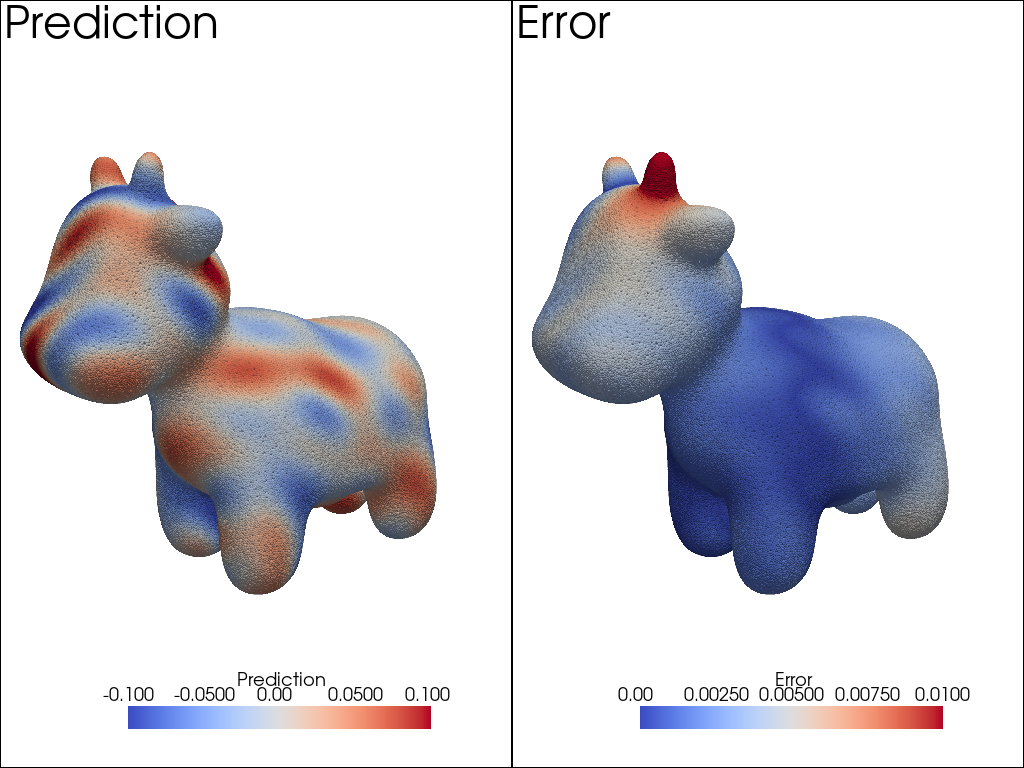

In [15]:
pv_data = pv.PolyData(data["xyz"].cpu().numpy()[collocation_mask])
pv_data["Prediction"] = pred
pv_data["Error"] = np.abs(pred - solution[collocation_mask])

camera_position = [
    (-5.540426247912693, 1.6662489557744946, -3.5168265303256296),
    (-0.05816924426784502, 0.08683893634845968, 0.05411275262662977),
    (0.16073463828406648, 0.9700217471130059, 0.1822695426655861),
]
scalar_bar_args = dict(position_x=0.25)

pl = pv.Plotter(shape=(1, 2))
pl.subplot(0, 0)
pl.add_text("Prediction", font_size=18)
pl.add_points(
    pv_data,
    point_size=6,
    render_points_as_spheres=True,
    scalars="Prediction",
    clim=[-0.1, 0.1],
    cmap="coolwarm",
    scalar_bar_args=scalar_bar_args,
)
pl.camera_position = camera_position
pl.camera.zoom(0.65)
pl.subplot(0, 1)
pl.add_text("Error", font_size=18)
pl.add_points(
    pv_data,
    point_size=6,
    render_points_as_spheres=True,
    scalars="Error",
    cmap="coolwarm",
    clim=[0, 0.01],
    copy_mesh=True,
    scalar_bar_args=scalar_bar_args,
)
pl.camera_position = camera_position
pl.camera.zoom(0.65)
pl.show()